In [3]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [ ]:
#Load Data
# Load the full dataset
df = pd.read_csv('../Dataset/covid.csv', low_memory=False)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (566602, 23)

Columns: ['id', 'sex', 'patient_type', 'entry_date', 'date_symptoms', 'date_died', 'intubed', 'pneumonia', 'age', 'pregnancy', 'diabetes', 'copd', 'asthma', 'inmsupr', 'hypertension', 'other_disease', 'cardiovascular', 'obesity', 'renal_chronic', 'tobacco', 'contact_other_covid', 'covid_res', 'icu']

First 5 rows:
All columns in your dataset:
0: 'id'
1: 'sex'
2: 'patient_type'
3: 'entry_date'
4: 'date_symptoms'
5: 'date_died'
6: 'intubed'
7: 'pneumonia'
8: 'age'
9: 'pregnancy'
10: 'diabetes'
11: 'copd'
12: 'asthma'
13: 'inmsupr'
14: 'hypertension'
15: 'other_disease'
16: 'cardiovascular'
17: 'obesity'
18: 'renal_chronic'
19: 'tobacco'
20: 'contact_other_covid'
21: 'covid_res'
22: 'icu'


In [8]:
#diagnositic cell
# Check what values covid_res actually contains
print("covid_res unique values:")
print(df['covid_res'].value_counts().sort_index())

print(f"\ndate_died unique values sample:")
print(df['date_died'].value_counts().head(10))

print(f"\nAny NaN in covid_res: {df['covid_res'].isnull().sum()}")
print(f"Any NaN in date_died: {df['date_died'].isnull().sum()}")

covid_res unique values:
covid_res
1    220657
2    279035
3     66910
Name: count, dtype: int64

date_died unique values sample:
date_died
9999-99-99    530426
08-06-2020       701
16-06-2020       699
10-06-2020       691
12-06-2020       674
09-06-2020       656
14-06-2020       641
17-06-2020       636
13-06-2020       634
06-06-2020       632
Name: count, dtype: int64

Any NaN in covid_res: 0
Any NaN in date_died: 0


In [9]:
#Replicate Paper's Extraction
# Paper used exactly these 6 features
# date_died: 9999-99-99 means alive, any date means died

# Create death column from date_died
# '9999-99-99' means alive, any actual date means died
df['death'] = df['date_died'].apply(lambda x: 1 if x == '9999-99-99' else 2)

# Select the 6 features paper used
features_paper = ['age', 'sex', 'diabetes', 'obesity', 'covid_res', 'death']
df_paper = df[features_paper].copy()

# Keep ONLY confirmed positive cases (covid_res = 1)
df_paper = df_paper[df_paper['covid_res'] == 1]

# Rename for clarity
df_paper.rename(columns={'covid_res': 'covid_result'}, inplace=True)

print(f"After filtering confirmed positive cases: {df_paper.shape}")
print(f"\nDeath distribution:")
print(df_paper['death'].value_counts())
print(f"\nDeath % breakdown:")
print(df_paper['death'].value_counts(normalize=True) * 100)

# Quick sanity check
print(f"\nAge range: {df_paper['age'].min()} to {df_paper['age'].max()}")
print(f"Sex values: {df_paper['sex'].unique()}")
print(f"Diabetes values: {df_paper['diabetes'].unique()}")
print(f"Obesity values: {df_paper['obesity'].unique()}")

After filtering confirmed positive cases: (220657, 6)

Death distribution:
death
1    193536
2     27121
Name: count, dtype: int64

Death % breakdown:
death
1    87.708978
2    12.291022
Name: proportion, dtype: float64

Age range: 0 to 120
Sex values: [2 1]
Diabetes values: [ 2  1 98]
Obesity values: [ 2  1 98]


In [10]:
#Sample 10,000 like the paper
# Paper took 10,000 samples - we replicate that
df_sample = df_paper.sample(n=10000, random_state=42)

print(f"Sample shape: {df_sample.shape}")
print(f"\nDeath distribution in sample:")
print(df_sample['death'].value_counts())
print(f"\nDeath % in sample:")
print(df_sample['death'].value_counts(normalize=True) * 100)

Sample shape: (10000, 6)

Death distribution in sample:
death
1    8772
2    1228
Name: count, dtype: int64

Death % in sample:
death
1    87.72
2    12.28
Name: proportion, dtype: float64


In [11]:
#Quick clean for Replication
# Replace 98 (missing code in this dataset) with NaN
# We saw 98 in diabetes and obesity columns
df_sample = df_sample.copy()
df_sample['diabetes'] = df_sample['diabetes'].replace(98, np.nan)
df_sample['obesity'] = df_sample['obesity'].replace(98, np.nan)

# Drop rows with NaN
df_sample.dropna(inplace=True)

print(f"After cleaning shape: {df_sample.shape}")
print(f"\nDiabetes unique values: {sorted(df_sample['diabetes'].unique())}")
print(f"Obesity unique values: {sorted(df_sample['obesity'].unique())}")
print(f"Sex unique values: {sorted(df_sample['sex'].unique())}")
print(f"\nDeath distribution after cleaning:")
print(df_sample['death'].value_counts())

After cleaning shape: (9959, 6)

Diabetes unique values: [np.float64(1.0), np.float64(2.0)]
Obesity unique values: [np.float64(1.0), np.float64(2.0)]
Sex unique values: [np.int64(1), np.int64(2)]

Death distribution after cleaning:
death
1    8739
2    1220
Name: count, dtype: int64


In [12]:
#Prepare Features and Target
# Features and target
X = df_sample[['age', 'sex', 'diabetes', 'obesity', 'covid_result']]
y = df_sample['death']

# Convert target: 1=survived→0, 2=died→1 for sklearn
y = y.map({1: 0, 2: 1})

print(f"X shape: {X.shape}")
print(f"\ny distribution:")
print(y.value_counts())
print(f"\nClass balance %:")
print(y.value_counts(normalize=True) * 100)

# Train test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")
print(f"\nTrain death distribution:")
print(y_train.value_counts())
print(f"\nTest death distribution:")
print(y_test.value_counts())

X shape: (9959, 5)

y distribution:
death
0    8739
1    1220
Name: count, dtype: int64

Class balance %:
death
0    87.749774
1    12.250226
Name: proportion, dtype: float64

Train size: 7967
Test size: 1992

Train death distribution:
death
0    6991
1     976
Name: count, dtype: int64

Test death distribution:
death
0    1748
1     244
Name: count, dtype: int64


In [13]:
#Train all 5 models
# Define all models like the paper
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

# Store results
results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })
    
    print(f"  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

print("\nDone training all models!")

Training Random Forest...
  Accuracy: 0.8630 | Precision: 0.8108 | Recall: 0.8630 | F1: 0.8279
Training Decision Tree...
  Accuracy: 0.8630 | Precision: 0.8073 | Recall: 0.8630 | F1: 0.8259
Training SVM...
  Accuracy: 0.8775 | Precision: 0.7700 | Recall: 0.8775 | F1: 0.8203
Training KNN...
  Accuracy: 0.8544 | Precision: 0.8090 | Recall: 0.8544 | F1: 0.8263
Training Logistic Regression...
  Accuracy: 0.8690 | Precision: 0.8133 | Recall: 0.8690 | F1: 0.8281

Done training all models!


In [14]:
#Results Table
# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("="*65)
print("PHASE 1 RESULTS - REPLICATION OF ORIGINAL PAPER")
print("="*65)
print(results_df.to_string(index=False))
print("="*65)

# Compare with paper's results
paper_results = pd.DataFrame({
    'Model': ['RF', 'DT', 'SVM', 'KNN', 'LR'],
    'Paper_Accuracy': [0.88, 0.88, 0.87, 0.86, 0.88]
})

print("\nPaper's reported accuracy: RF=0.88, DT=0.88, SVM=0.87, KNN=0.86, LR=0.88")
print("Our replication accuracy shown above - compare and verify!")

PHASE 1 RESULTS - REPLICATION OF ORIGINAL PAPER
              Model  Accuracy  Precision  Recall  F1-Score
                SVM    0.8775     0.7700  0.8775    0.8203
Logistic Regression    0.8690     0.8133  0.8690    0.8281
      Random Forest    0.8630     0.8108  0.8630    0.8279
      Decision Tree    0.8630     0.8073  0.8630    0.8259
                KNN    0.8544     0.8090  0.8544    0.8263

Paper's reported accuracy: RF=0.88, DT=0.88, SVM=0.87, KNN=0.86, LR=0.88
Our replication accuracy shown above - compare and verify!


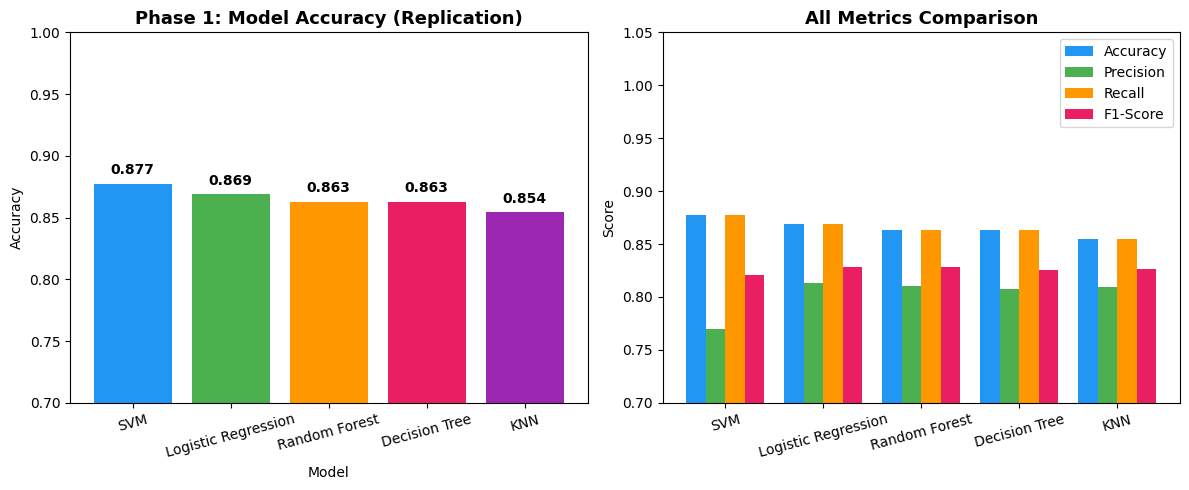

Phase 1 Complete! Results saved.


In [16]:
#Visualise Results
plt.figure(figsize=(12, 5))

# Plot 1: Accuracy comparison
plt.subplot(1, 2, 1)
bars = plt.bar(results_df['Model'], results_df['Accuracy'], 
               color=['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0'])
plt.ylim(0.7, 1.0)
plt.title('Phase 1: Model Accuracy (Replication)', fontsize=13, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
for bar, val in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: All metrics comparison
plt.subplot(1, 2, 2)
x = np.arange(len(results_df['Model']))
width = 0.2
plt.bar(x - width*1.5, results_df['Accuracy'], width, label='Accuracy', color='#2196F3')
plt.bar(x - width*0.5, results_df['Precision'], width, label='Precision', color='#4CAF50')
plt.bar(x + width*0.5, results_df['Recall'], width, label='Recall', color='#FF9800')
plt.bar(x + width*1.5, results_df['F1-Score'], width, label='F1-Score', color='#E91E63')
plt.ylim(0.7, 1.05)
plt.title('All Metrics Comparison', fontsize=13, fontweight='bold')
plt.xticks(x, results_df['Model'], rotation=15)
plt.legend()
plt.ylabel('Score')

plt.tight_layout()
plt.savefig('phase1_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Phase 1 Complete! Results saved.")